## Finetuned Model Post-Processing

**Heads**

Default: your custom head (for the dataset you gave `--train-file` earlier)

pt_head: pre-training/replay head, samples drawn from the replay .xyz file, a snapshot of the original foundation model's training set

In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
# ==== USER INPUT HERE ====
RUN_ID = 731507

out_file = f"mace_{str(RUN_ID)}.out"
err_file = f"mace_{str(RUN_ID)}.err"
train_script = f"train_{str(RUN_ID)}.sbatch"

In [3]:
# load in job.out generated by training run

pattern = re.compile(
    r"(?:Epoch (\d+)|(Initial)): head: (\S+), loss=([\d.]+), "
    r"RMSE_E_per_atom=\s*([\d.]+) meV, "
    r"RMSE_F=\s*([\d.]+) meV / A, "
    r"RMSE_stress=\s*([\d.]+) meV / A\^3"
)

with open(f"../logs/{out_file}", "r") as f:
    log_out = f.read()

matches = pattern.findall(log_out)

rows = [
    (epoch_num if epoch_num else "-1", *rest)
    for epoch_num, _initial, *rest in matches
]

# make dataframe of epoch readouts
df = pd.DataFrame(
    rows,
    columns=["epoch", "head", "loss", "RMSE_E_per_atom", "RMSE_F", "RMSE_stress"]
)

numeric_cols = ["epoch", "loss", "RMSE_E_per_atom", "RMSE_F", "RMSE_stress"]
df[numeric_cols] = df[numeric_cols].astype(float)
df["epoch"] = df["epoch"].astype(int)

# separate out dfs for each model head
df_default = df[df["head"] == "Default"]
df_pt = df[df["head"] == "pt_head"]

print(f"df length: {len(df_default)}")

df length: 31


In [7]:
# get learning rate params

with open(f"../logs/{train_script}", "r") as f:
    text = f.read()

lr = re.search(r"--lr (\d+\.\d+)", text)
swa_lr = re.search(r"--swa_lr (\d+\.\d+)", text)

lr = float(lr.group(1)) if lr else None
swa_lr = float(swa_lr.group(1)) if swa_lr else None

Graph Loss

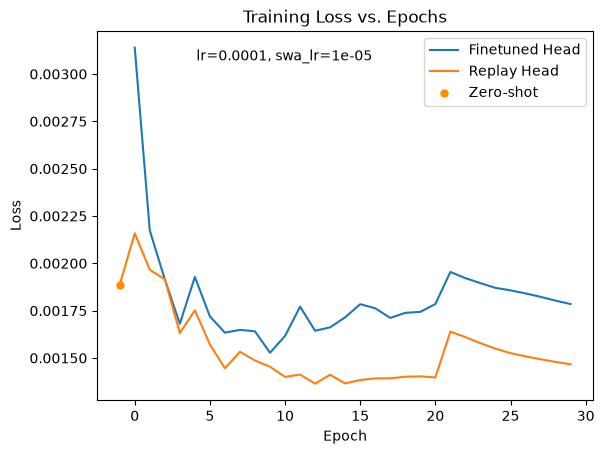

In [14]:
# remove meaningless initial point of tuned head
df_default_plot = df_default[df_default["epoch"] != -1]

# plot loss curves
plt.plot(df_default_plot["epoch"], df_default_plot["loss"], label="Finetuned Head")
plt.plot(df_pt["epoch"], df_pt["loss"], label="Replay Head")

# plot initial guess (zero-shot)
plt.scatter(
    df_pt["epoch"].iloc[0],
    df_pt["loss"].iloc[0],
    marker=".", s=100, color="darkorange", zorder=5, label="Zero-shot"
)

# print learning rates
plt.text(
    0.2, 0.95,
    f"lr={lr}, swa_lr={swa_lr}",
    transform=plt.gca().transAxes,
    ha="left",
    va="top",
)

plt.title("Training Loss vs. Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

Graph RMSE

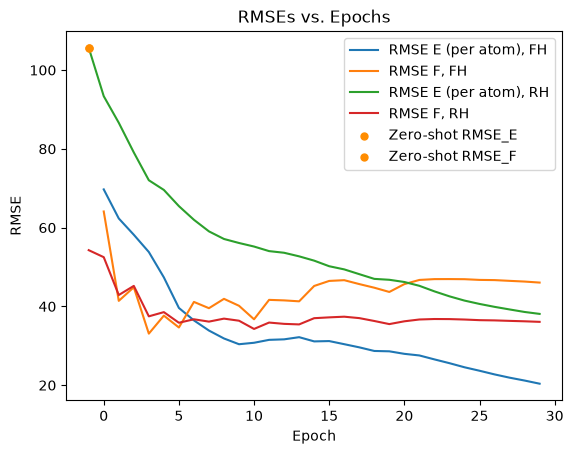

In [19]:
# plot RMSEs
plt.plot(df_default_plot["epoch"], df_default_plot["RMSE_E_per_atom"], label="RMSE E (per atom), FH")
plt.plot(df_default_plot["epoch"], df_default_plot["RMSE_F"], label="RMSE F, FH")

plt.plot(df_pt["epoch"], df_pt["RMSE_E_per_atom"], label="RMSE E (per atom), RH")
plt.plot(df_pt["epoch"], df_pt["RMSE_F"], label="RMSE F, RH")

# plot initial guess (zero-shot)
plt.scatter(
    df_pt["epoch"].iloc[0],
    df_pt["RMSE_E_per_atom"].iloc[0],
    marker=".", s=100, color="darkorange", zorder=5, label="Zero-shot RMSE_E"
)

plt.scatter(
    df_pt["epoch"].iloc[0],
    df_pt["RMSE_E_per_atom"].iloc[0],
    marker=".", s=100, color="darkorange", zorder=5, label="Zero-shot RMSE_F"
)


plt.title("RMSEs vs. Epochs")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.legend()

In [16]:
print(df_default)
print(df_pt)

    epoch     head      loss  RMSE_E_per_atom  RMSE_F  RMSE_stress
1      -1  Default  0.000107           107.57    0.00         0.00
3       0  Default  0.003139            69.71   64.10         9.71
5       1  Default  0.002174            62.33   41.41        11.58
7       2  Default  0.001916            58.19   44.86        10.52
9       3  Default  0.001681            53.81   33.09         7.90
11      4  Default  0.001928            47.37   37.66         9.88
13      5  Default  0.001720            39.61   34.65         9.35
15      6  Default  0.001634            36.45   41.14        10.39
17      7  Default  0.001649            33.87   39.55        11.30
19      8  Default  0.001641            31.86   41.92        11.55
21      9  Default  0.001528            30.40   40.16        10.80
23     10  Default  0.001617            30.77   36.73        10.30
25     11  Default  0.001771            31.51   41.66         9.84
27     12  Default  0.001644            31.64   41.53        1

### Notes

**run_731507**
Zero-shot: for pt_head (the replay head) @ epoch 0, RMSE_E_per_atom: 105.68, RMSE_F: 54.28

**run_731457**

Loss curves indicate
* Catastrophic forgetting: finetuned loss jumps far above replay at the end
 
3 main issues:
1. massive jump in loss from epoch 20 --> 21. to me, this indicates an issue with how SWA is being set/used
2. post-SWA doesn't have enough epochs to potentially converge. 30 is not many epochs, but the finetuning docs said this should converge in 10-30 epochs
3. we didn't really seem to use the first 20 epochs well? loss decreases for the first 5 epochs but then kind of levels off and skips around. the finetune head has min loss around epoch 6, and the replay head hits a min loss around epochs 6 and 20

default lr=0.01, our lr=0.0005
default swa_lr=0.001, our swa_lr=default

On learning rate:  
b/c we have a small dataset (compared to what the literature uses for finetuning MACE), i decreased the lr. smaller corpus --> fewer samples per batch --> noisier\* gradient estimates --> large step size overshoots local minima 

however, swa<=lr, usually set swa = lr/(10-100) 
looking back, finetuning lr=0.0001 in some lit., so lower that as well

\* (higher variance in estimate of "true" gradient, the gradient of loss computed over the entire dataset)